## Student Performance Indicator

### Life Cycle of Machine Learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to Perform
- Exploratory Data Analysis
- Data Preprocessing
- Model Training
- Choose Best Model


### 1) Problem Statement

- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course


### 2) Data Collection

- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams
- The data consists of 8 columns and 1000 rows


#### 2.1 Import Data and Required Packages

Importing Pandas, Numpy, Matplotlib, Seaborn and Warnings Library


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings("ignore")

##### Import the CSV Data as Pandas DataFrame


In [2]:
df = pd.read_csv("data/stud.csv")

##### Show Top 5 Records


In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


##### Shape of the Dataset


In [4]:
df.shape

(1000, 8)

#### 2.2 Dataset Information

<table>
  <thead>
    <tr>
      <th>No</th>
      <th>Column</th>
      <th>Information</th>
      <th>Unique Values</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>1</td>
      <td>Gender</td>
      <td>Sex of students</td>
      <td>Male, Female</td>
    </tr>
    <tr>
      <td>2</td>
      <td>Race/Ethnicity</td>
      <td>Enthnicity of students</td>
      <td>A, B, C, D, E</td>
    </tr>
    <tr>
      <td>3</td>
      <td>Parental Level of Education</td>
      <td>Parent's final education</td>
      <td>Bachelor's degree, some college, master's degree, associate's degree, high school</td>
    </tr>
    <tr>
      <td>4</td>
      <td>Lunch</td>
      <td>Having lunch before test</td>
      <td>Standard, tree/reduced</td>
    </tr>
    <tr>
      <td>5</td>
      <td>Test Preparation Course</td>
      <td>Complete or not complete before test</td>
      <td>Complete, Not Complete</td>
    </tr>
    <tr>
      <td>6</td>
      <td>Math Score</td>
      <td>Score of math that student get after exam</td>
      <td></td>
    </tr>
    <tr>
      <td>7</td>
      <td>Reading Score</td>
      <td>Score of reading that student get after exam</td>
      <td></td>
    </tr>
    <tr>
      <td>8</td>
      <td>Writing Score</td>
      <td>Score of writing that student get after exam</td>
      <td></td>
    </tr>
  </tbody>
</table>


### 3) Data Checks to Perform

- Check Missing Values
- Check Duplicates
- Check Data Type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column


#### 3.1 Check Missing Values


In [5]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

There are no missing values in the dataset


#### 3.2 Check Duplicates


In [6]:
df.duplicated().sum()

0

There are no duplicates values in the dataset


#### 3.3 Check Data Type


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


There are 5 categorical features and 3 numerical features


#### 3.4 Checking the number of unique values of each column


In [8]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

#### 3.5 Check statistics of dataset


In [9]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


##### Insight

- From above description of numerical data, all means are very close to each other - between 66 and 68.05
- All standard deviations are also close - between 14.6 and 15.19
- While there is a minimum score 0 for math, for writing minimum is higher (10) and for reading more higher (17)


#### 3.6 Check various categories present in categorical features


In [10]:
cat_features = [feature for feature in df.columns if df[feature].dtype == "O"]

for feature in cat_features:
    print("{0}:\n".format(feature), df[feature].unique())
    print()

gender:
 ['female' 'male']

race_ethnicity:
 ['group B' 'group C' 'group A' 'group D' 'group E']

parental_level_of_education:
 ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']

lunch:
 ['standard' 'free/reduced']

test_preparation_course:
 ['none' 'completed']



#### 3.7 Exploring Data


In [11]:
num_features = [feature for feature in df.columns if df[feature].dtype != "O"]
cat_features = [feature for feature in df.columns if df[feature].dtype == "O"]

print("We have {} numerical features: {}".format(len(num_features), num_features))
print("\nWe have {} categorical features: {}".format(len(cat_features), cat_features))

We have 3 numerical features: ['math_score', 'reading_score', 'writing_score']

We have 5 categorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


#### 3.8 Adding columns for Total Score and Average


In [12]:
df["total_score"] = df["math_score"] + df["reading_score"] + df["writing_score"]
df["average"] = df["total_score"] / 3

df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [13]:
reading_full = df[df["reading_score"] == 100]["average"].count()
writing_full = df[df["writing_score"] == 100]["average"].count()
math_full = df[df["math_score"] == 100]["average"].count()

print(f"Number of students with full marks in Math: {math_full}")
print(f"Number of students with full marks in Writing: {writing_full}")
print(f"Number of students with full marks in Reading: {reading_full}")

Number of students with full marks in Math: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [14]:
reading_full = df[df["reading_score"] < 20]["average"].count()
writing_full = df[df["writing_score"] < 20]["average"].count()
math_full = df[df["math_score"] < 20]["average"].count()

print(f"Number of students with less than 20 marks in Math: {math_full}")
print(f"Number of students with less than 20 marks in Writing: {writing_full}")
print(f"Number of students with less than 20 marks in Reading: {reading_full}")

Number of students with less than 20 marks in Math: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


##### Insights

- From above values, we get students have performed the worst in Maths
- Best performance is in reading section


### 4. Exploring Data (Visualization)


#### 4.1 Visualize average score distribution to make some conclusion.

- Histogram
- Kernel Distribution Function (KDE)


##### 4.1.1 Histogram & KDE


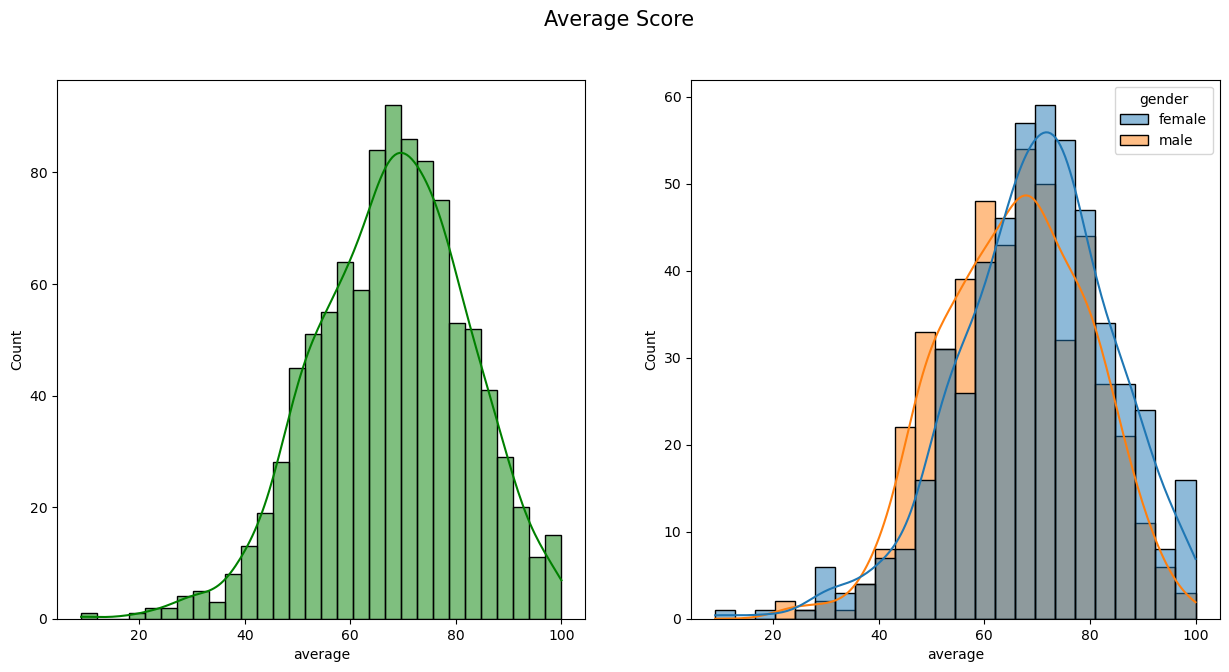

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

fig.suptitle("Average Score", fontsize=15)

plt.subplot(121)
sns.histplot(data=df, x="average", bins=30, kde=True, color="g")

plt.subplot(122)
sns.histplot(data=df, x="average", kde=True, hue="gender")

plt.show()

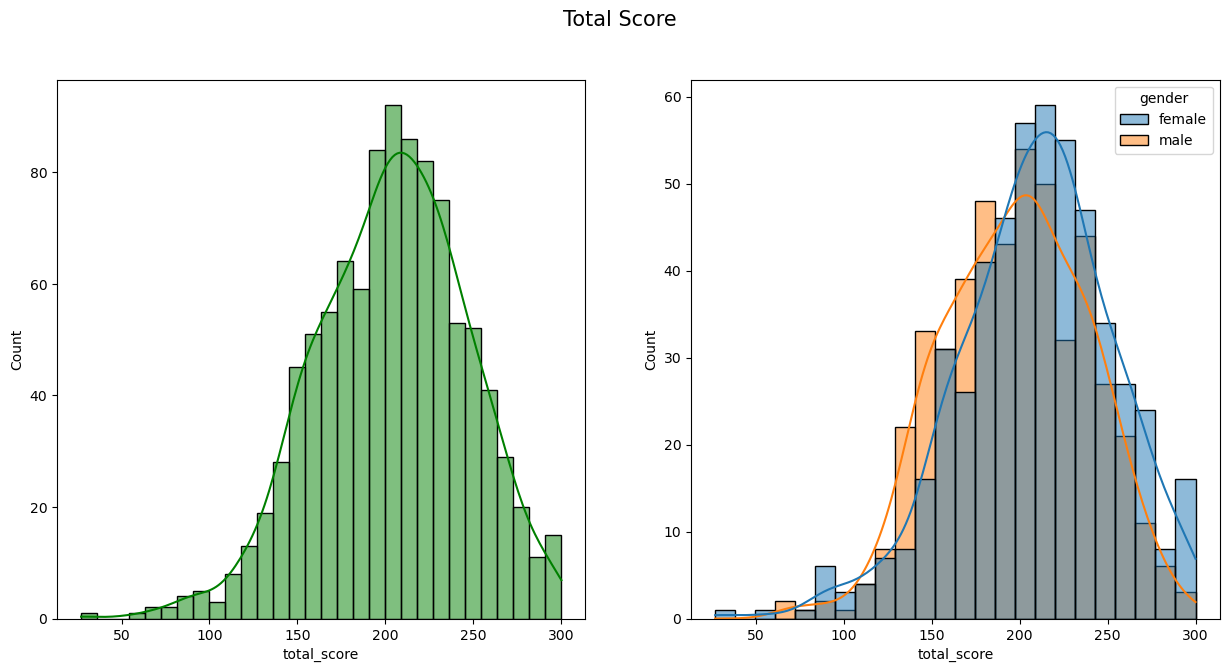

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

fig.suptitle("Total Score", fontsize=15)

plt.subplot(121)
sns.histplot(data=df, x="total_score", bins=30, kde=True, color="g")

plt.subplot(122)
sns.histplot(data=df, x="total_score", kde=True, hue="gender")

plt.show()

Female students thed to perform well then male students.


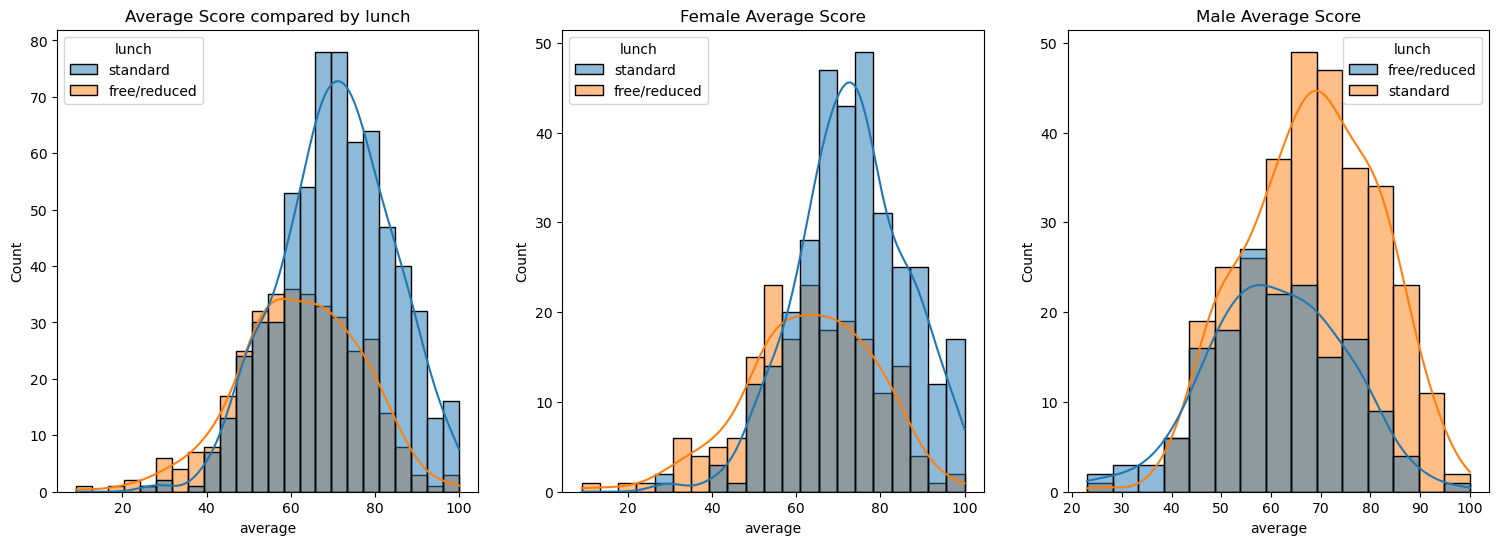

In [17]:
fig, axs = plt.subplots(1, 3, figsize=(25, 6))

plt.subplot(141)
sns.histplot(data=df, x="average", kde=True, hue="lunch")
plt.title("Average Score compared by lunch")

plt.subplot(142)
sns.histplot(data=df[df.gender == "female"], x="average", kde=True, hue="lunch")
plt.title("Female Average Score")

plt.subplot(143)
sns.histplot(data=df[df.gender == "male"], x="average", kde=True, hue="lunch")
plt.title("Male Average Score")


plt.show()

Standard lunch helps perform well in exams either for male or female


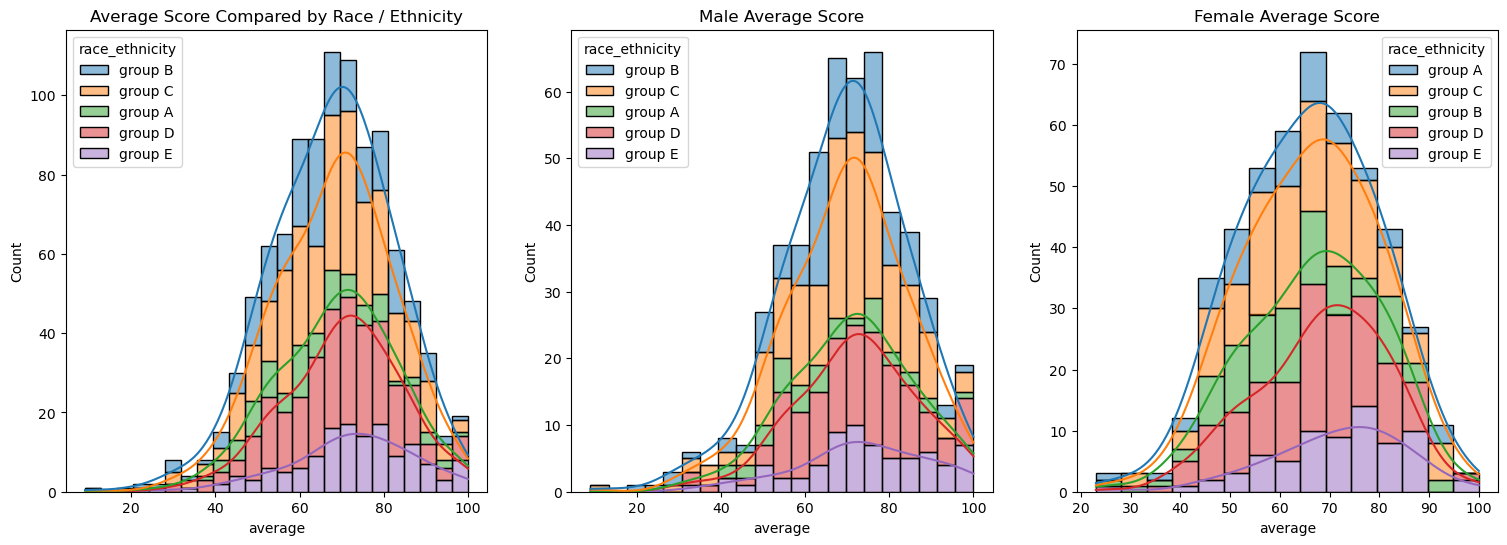

In [18]:
fig, axs = plt.subplots(1, 3, figsize=(25, 6))

plt.subplot(141)
sns.histplot(data=df, x="average", hue="race_ethnicity", multiple="stack", kde=True)
plt.title("Average Score Compared by Race / Ethnicity")


plt.subplot(142)
sns.histplot(
    data=df[df.gender == "female"],
    x="average",
    hue="race_ethnicity",
    multiple="stack",
    kde=True,
)
plt.title("Male Average Score")

plt.subplot(143)
sns.histplot(
    data=df[df.gender == "male"],
    x="average",
    hue="race_ethnicity",
    multiple="stack",
    kde=True,
)
plt.title("Female Average Score")

plt.show()

- Female section still performs better even in every race
- Group B has the highest average score in overall and male section
- Meanwhile, in female section, the group that earned highest average score is Group A


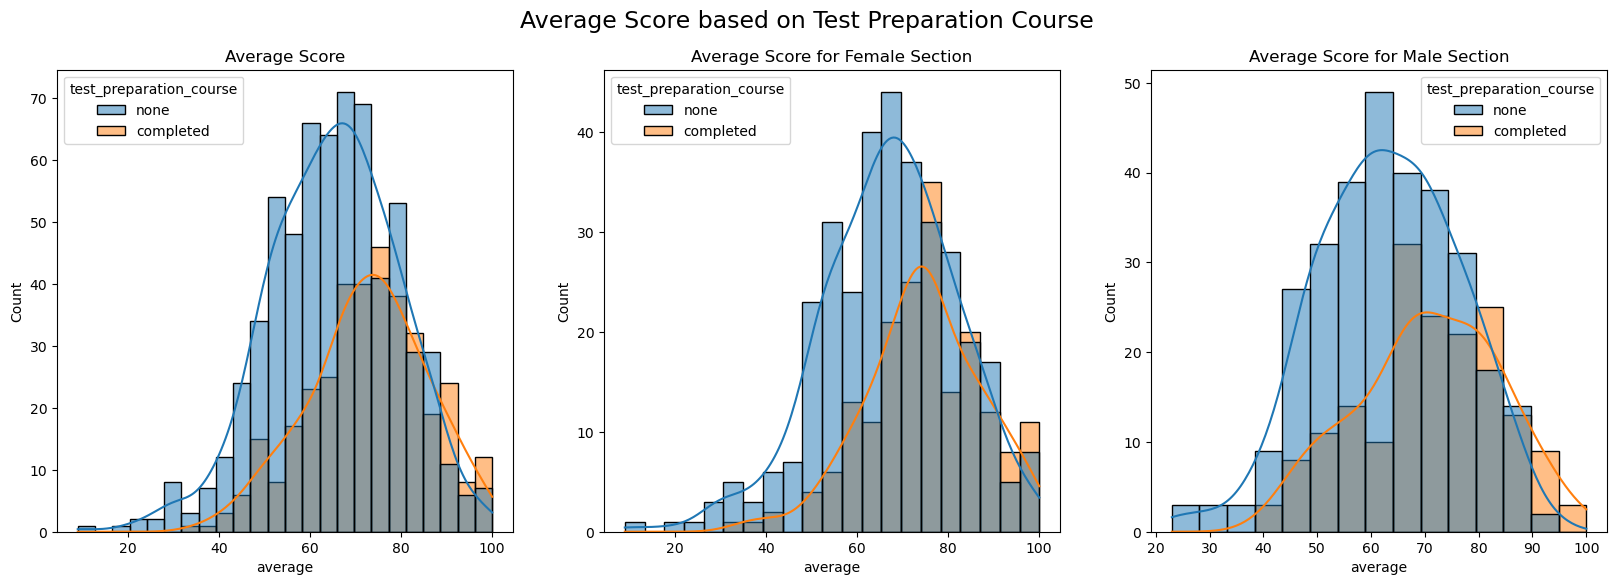

In [19]:
fig, ax = plt.subplots(
    1,
    3,
    figsize=(20, 6),
)

sns.histplot(data=df, x="average", hue="test_preparation_course", kde=True, ax=ax[0])
ax[0].set_title("Average Score")

sns.histplot(
    data=df[df.gender == "female"],
    x="average",
    hue="test_preparation_course",
    kde=True,
    ax=ax[1],
)
ax[1].set_title("Average Score for Female Section")

sns.histplot(
    data=df[df.gender == "male"],
    x="average",
    hue="test_preparation_course",
    kde=True,
    ax=ax[2],
)
ax[2].set_title("Average Score for Male Section")

fig.suptitle("Average Score based on Test Preparation Course", fontsize=17)

plt.show()

- Both female and male mostly didn't take preparation before exam.
- Students who took preparation has higher average score for both male and female
- Test Preparation greatly affects student's average scores for the upcoming exam


In [20]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'total_score', 'average'],
      dtype='object')

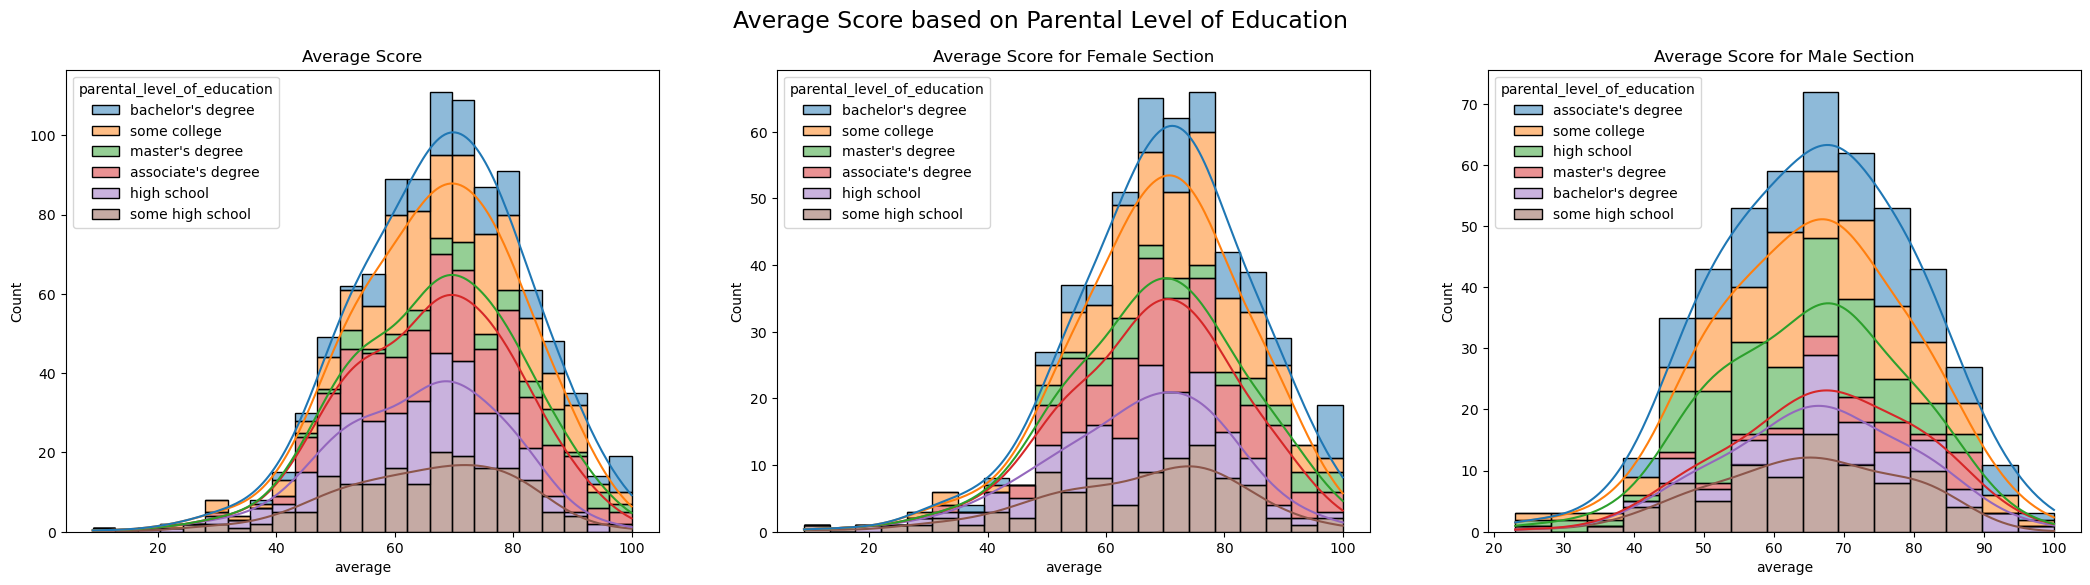

In [21]:
fig, ax = plt.subplots(
    1,
    3,
    figsize=(26, 6),
)

sns.histplot(
    data=df,
    x="average",
    hue="parental_level_of_education",
    kde=True,
    ax=ax[0],
    multiple="stack",
)
ax[0].set_title("Average Score")

sns.histplot(
    data=df[df.gender == "female"],
    x="average",
    hue="parental_level_of_education",
    kde=True,
    ax=ax[1],
    multiple="stack",
)
ax[1].set_title("Average Score for Female Section")

sns.histplot(
    data=df[df.gender == "male"],
    x="average",
    hue="parental_level_of_education",
    kde=True,
    ax=ax[2],
    multiple="stack",
)
ax[2].set_title("Average Score for Male Section")

fig.suptitle("Average Score based on Parental Level of Education", fontsize=17)

plt.show()

- Student who has parents with bachelor's degree has the highest average score for female section
- Meanwhile in the male section, students whose parents hold a D3 diploma have the highest scores compared to the others.
- In general, parent's education don't help student perform well in exam


#### 4.2 Maximum Score of Students in All Three Subjects


In [22]:
df.describe()

,math_score,reading_score,writing_score,total_score,average
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,203.312000,67.770667
std,15.16308,14.600192,15.195657,42.771978,14.257326
min,0.00000,17.000000,10.000000,27.000000,9.000000
25%,57.00000,59.000000,57.750000,175.000000,58.333333
50%,66.00000,70.000000,69.000000,205.000000,68.333333
75%,77.00000,79.000000,79.000000,233.000000,77.666667
max,100.00000,100.000000,100.000000,300.000000,100.000000


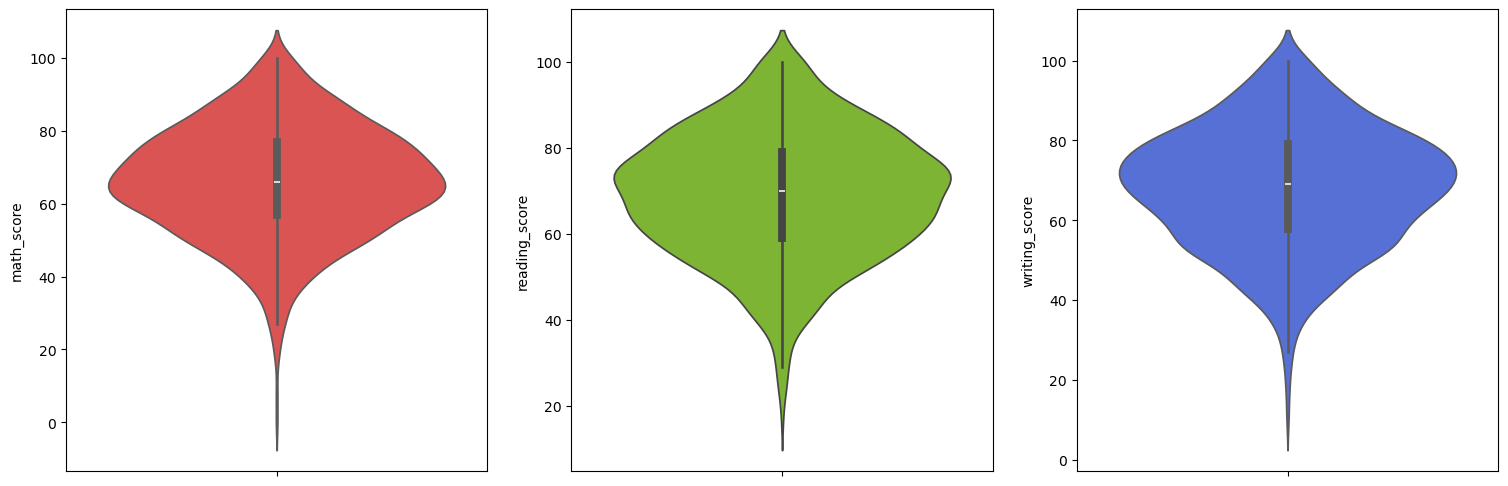

In [23]:
fig, ax = plt.subplots(1, 3, figsize=(25, 6))

plt.subplot(141)
sns.violinplot(y="math_score", data=df, color="#f03e3e")

plt.subplot(142)
sns.violinplot(y="reading_score", data=df, color="#82c91e")

plt.subplot(143)
sns.violinplot(y="writing_score", data=df, color="#4263eb")

plt.show()

#### 4.3 Multivariate Analysis Using Pie Plot


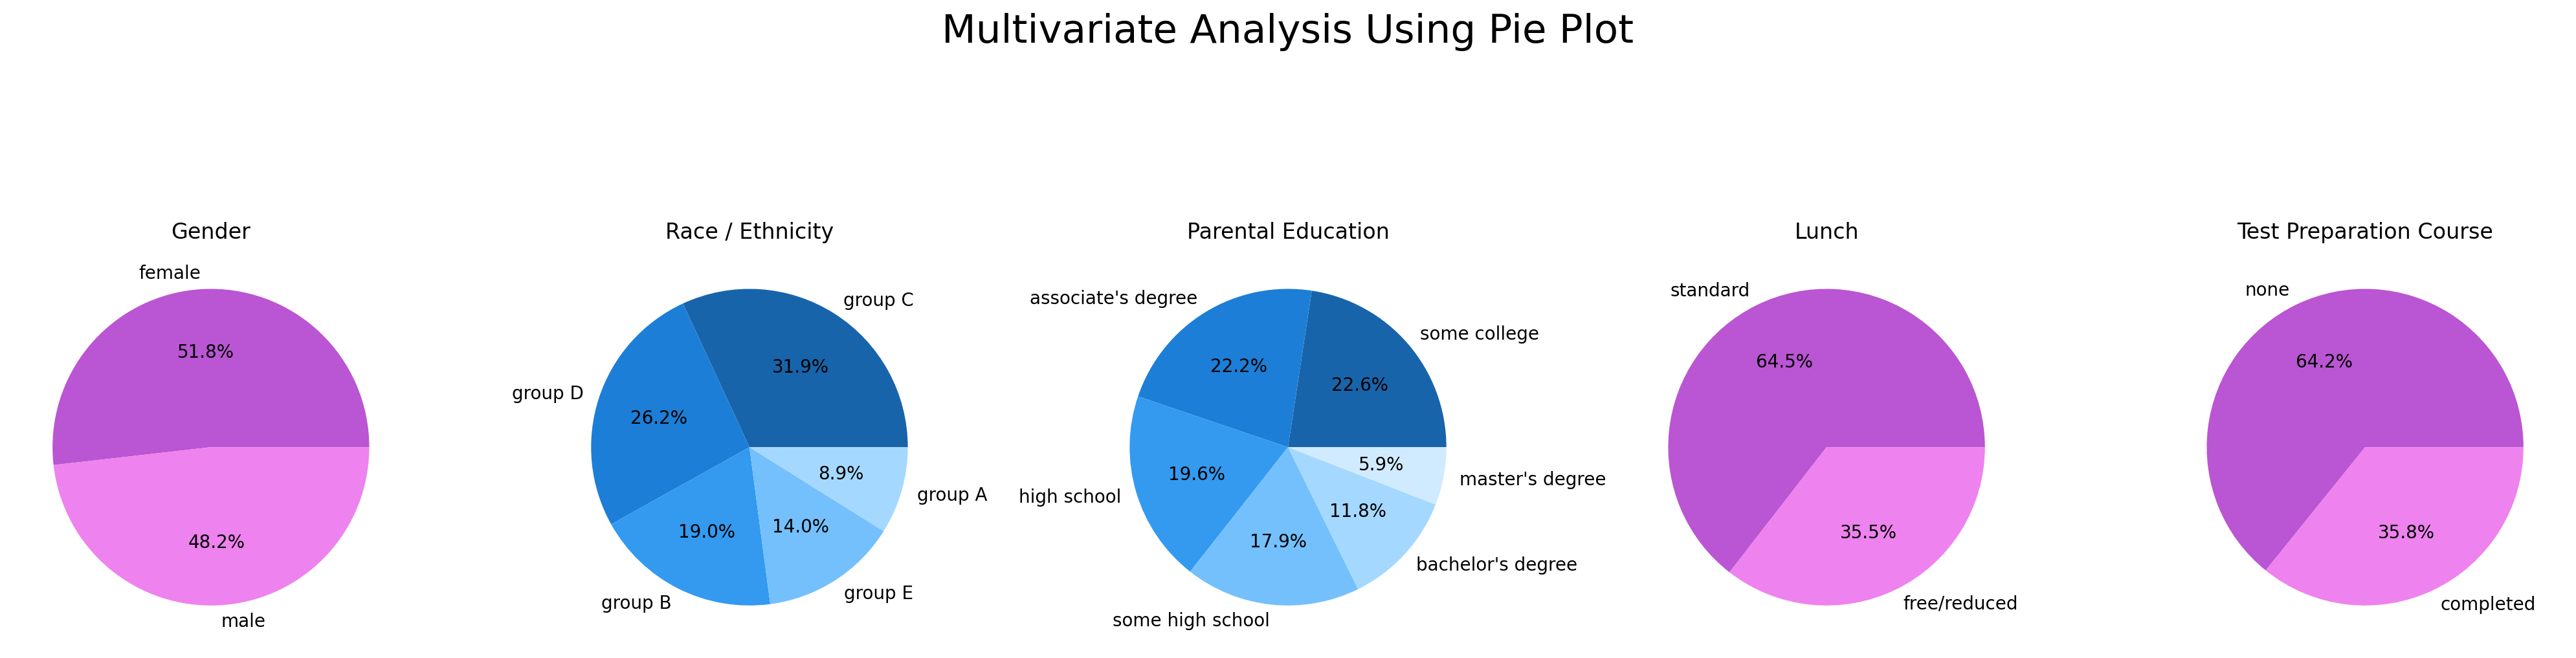

In [24]:
c1 = ["mediumorchid", "violet"]
c2 = ["#1864ab", "#1c7ed6", "#339af0", "#74c0fc", "#a5d8ff", "#d0ebff"]

fig, ax = plt.subplots(1, 5, figsize=(20, 7), dpi=200)

gender_analysis = df["gender"].value_counts()

plt.subplot(1, 5, 1)
plt.title("Gender")
plt.pie(
    gender_analysis.values, labels=gender_analysis.index, colors=c1, autopct="%1.1f%%"
)


race_analysis = df["race_ethnicity"].value_counts()

plt.subplot(1, 5, 2)
plt.title("Race / Ethnicity")
plt.pie(race_analysis.values, labels=race_analysis.index, colors=c2, autopct="%1.1f%%")


parental_analysis = df["parental_level_of_education"].value_counts()

plt.subplot(1, 5, 3)
plt.title("Parental Education")
plt.pie(
    parental_analysis.values,
    labels=parental_analysis.index,
    colors=c2,
    autopct="%1.1f%%",
)


lunch_analysis = df["lunch"].value_counts()

plt.subplot(1, 5, 4)
plt.title("Lunch")
plt.pie(
    lunch_analysis.values, labels=lunch_analysis.index, colors=c1, autopct="%1.1f%%"
)


prep_analysis = df["test_preparation_course"].value_counts()

plt.subplot(1, 5, 5)
plt.title("Test Preparation Course")
plt.pie(prep_analysis.values, labels=prep_analysis.index, colors=c1, autopct="%1.1f%%")

plt.tight_layout()

fig.suptitle("Multivariate Analysis Using Pie Plot", fontsize=22)

plt.show()

#### 4.4 Feature Wise Visualization


##### 4.4.1 GENDER COLUMN

- How is distribution of Gender?
- Is gender has any impact on student's performance?


**Univariate Analysis (How is distribution of Gender?)**


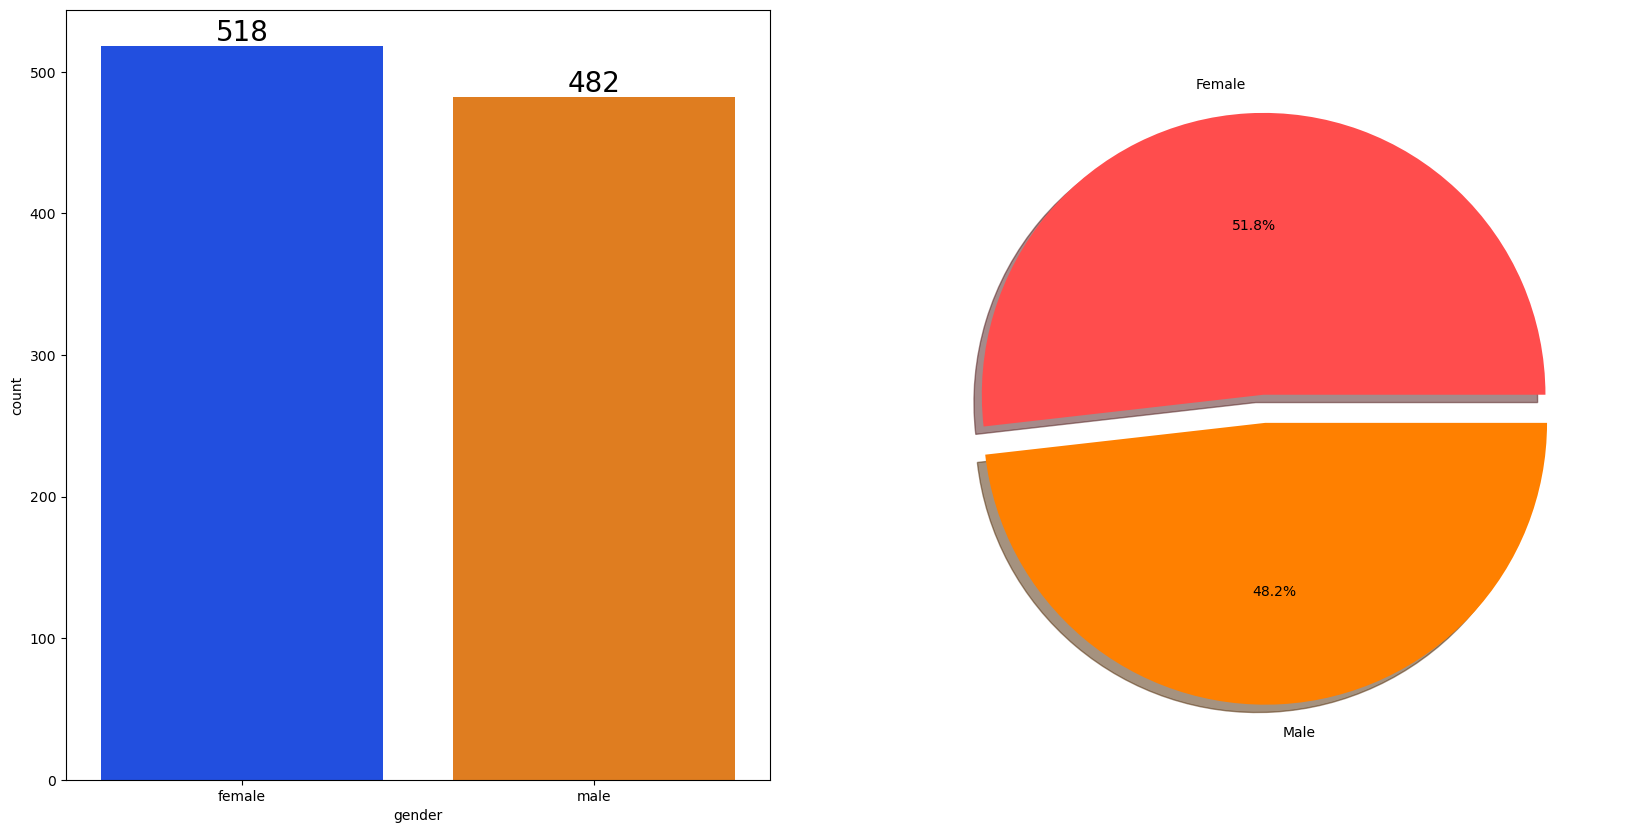

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
sns.countplot(x=df["gender"], data=df, palette="bright", ax=ax[0])
for container in ax[0].containers:
    ax[0].bar_label(container, color="black", size=20)

plt.pie(
    x=df["gender"].value_counts(),
    labels=["Female", "Male"],
    explode=[0, 0.1],
    autopct="%1.1f%%",
    shadow=True,
    colors=["#ff4d4d", "#ff8000"],
)

plt.show()

Gender has balanced data with female students are 518 (52%) and male students are 482 (52%)


**Bivariate Analysis (Is gender has any impact on student's performance?)**


In [26]:
gender_group = df.groupby("gender")[
    ["math_score", "reading_score", "writing_score", "total_score", "average"]
].mean()

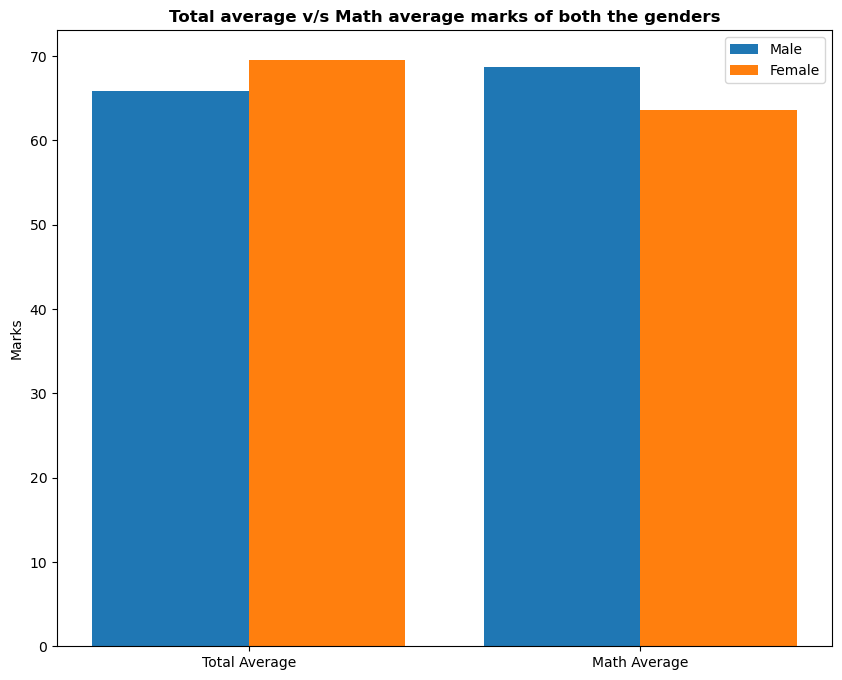

In [27]:
plt.figure(figsize=(10, 8))

X = ["Total Average", "Math Average"]

female_scores = [gender_group["average"][0], gender_group["math_score"][0]]
male_scores = [gender_group["average"][1], gender_group["math_score"][1]]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, male_scores, 0.4, label="Male")
plt.bar(X_axis + 0.2, female_scores, 0.4, label="Female")

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight="bold")
plt.legend()

plt.show()

- On an average females have a better overall score than men.
- Whereas males have scored higher in Maths


##### 4.4.2 RACE/ETHNICITY COLUMN

- How is distribution of Race?
- Is Race has any impact on student's performance?


**UNIVARIATE ANALYSIS (How is distribution of Race?)**


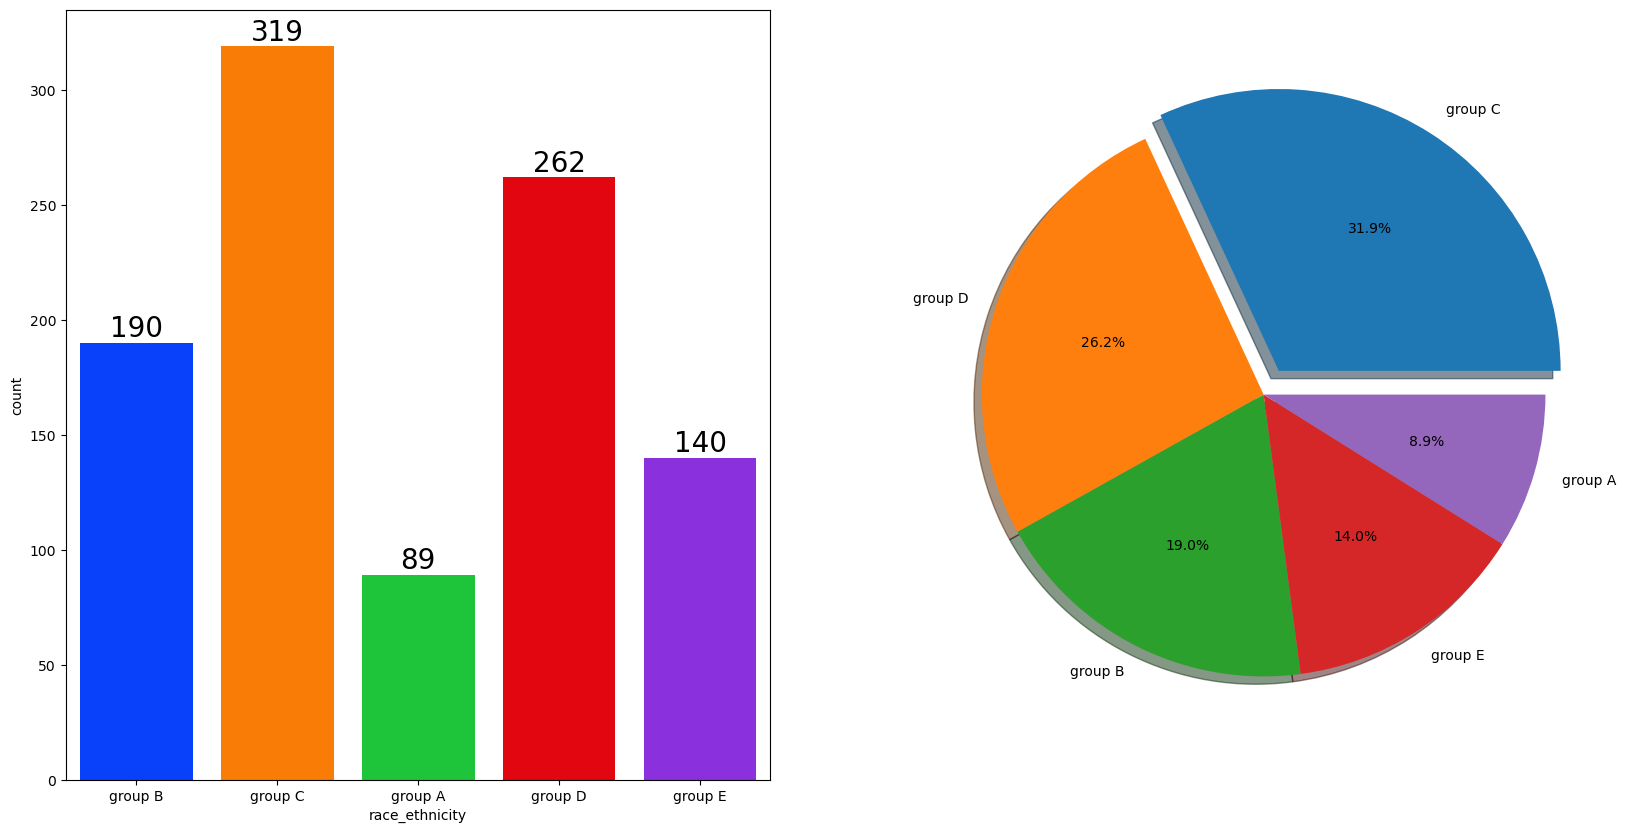

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
sns.countplot(
    x=df["race_ethnicity"], data=df, palette="bright", ax=ax[0], saturation=0.95
)
for container in ax[0].containers:
    ax[0].bar_label(container, color="black", size=20)

plt.pie(
    x=df["race_ethnicity"].value_counts(),
    labels=df["race_ethnicity"].value_counts().index,
    explode=[0.1, 0, 0, 0, 0],
    autopct="%1.1f%%",
    shadow=True,
)

plt.show()

**BIVARIATE ANALYSIS (Is Race has any impact on student's performance?)**


In [29]:
race_group = df.groupby("race_ethnicity")[
    ["math_score", "reading_score", "writing_score", "total_score", "average"]
].mean()

race_group

,math_score,reading_score,writing_score,total_score,average
race_ethnicity,,,,,
group A,61.629213,64.674157,62.674157,188.977528,62.992509
group B,63.452632,67.352632,65.600000,196.405263,65.468421
group C,64.463950,69.103448,67.827586,201.394984,67.131661
group D,67.362595,70.030534,70.145038,207.538168,69.179389
group E,73.821429,73.028571,71.407143,218.257143,72.752381


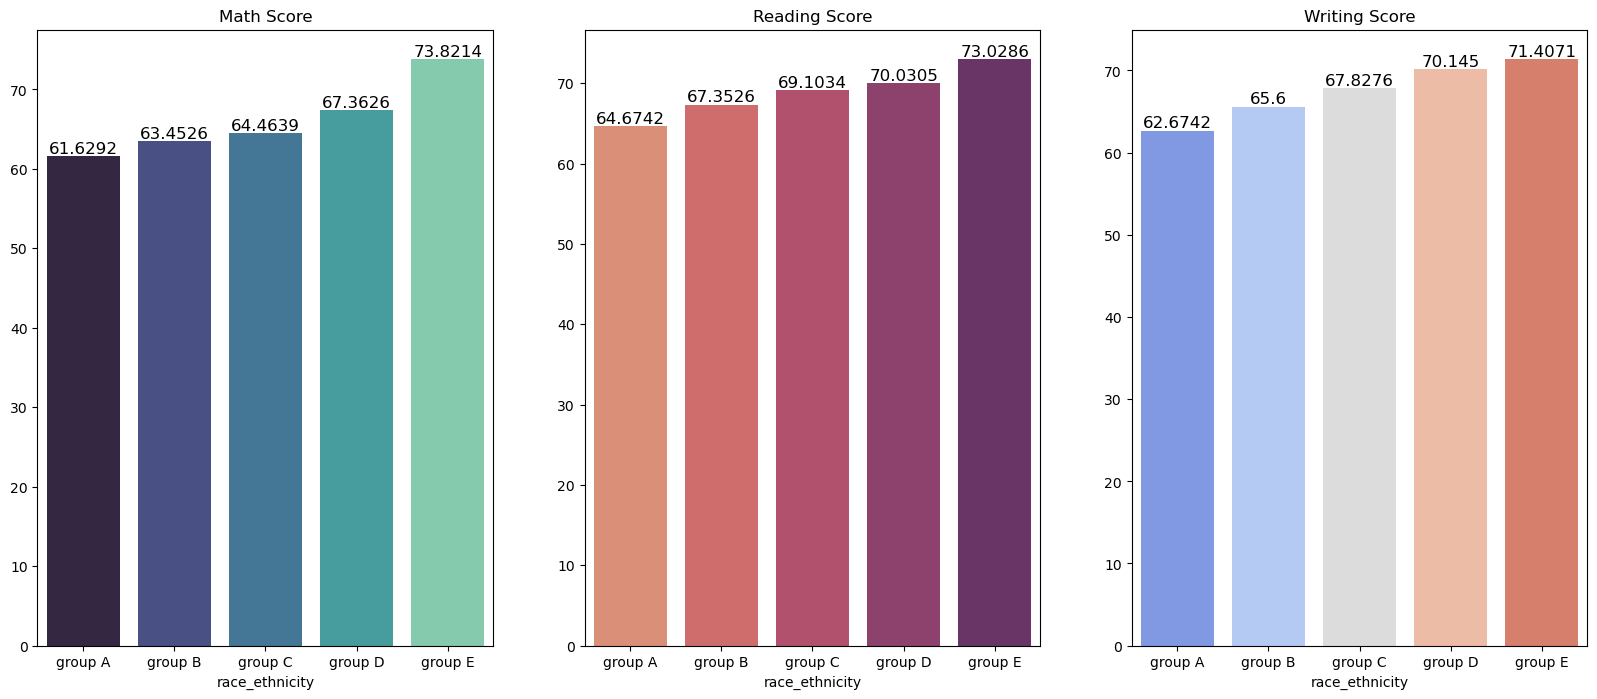

In [30]:
fig, ax = plt.subplots(1, 3, figsize=(20, 8))

sns.barplot(
    x=race_group["math_score"].index,
    y=race_group["math_score"].values,
    palette="mako",
    ax=ax[0],
)
ax[0].set_title("Math Score")
for container in ax[0].containers:
    ax[0].bar_label(container, color="black", size=12)

sns.barplot(
    x=race_group["reading_score"].index,
    y=race_group["reading_score"].values,
    palette="flare",
    ax=ax[1],
)
ax[1].set_title("Reading Score")
for container in ax[1].containers:
    ax[1].bar_label(container, color="black", size=12)

sns.barplot(
    x=race_group["writing_score"].index,
    y=race_group["writing_score"].values,
    palette="coolwarm",
    ax=ax[2],
)
ax[2].set_title("Writing Score")
for container in ax[2].containers:
    ax[2].bar_label(container, color="black", size=12)

plt.show()

##### 4.4.3 PARENTAL LEVEL OF EDUCATION LEVEL COLUMN

- What is educational background of student's parent ?
- Is parental education has any impact on student's performance ?


**UNIVARIATE ANALYSIS (What is educational background of student's parent?)**


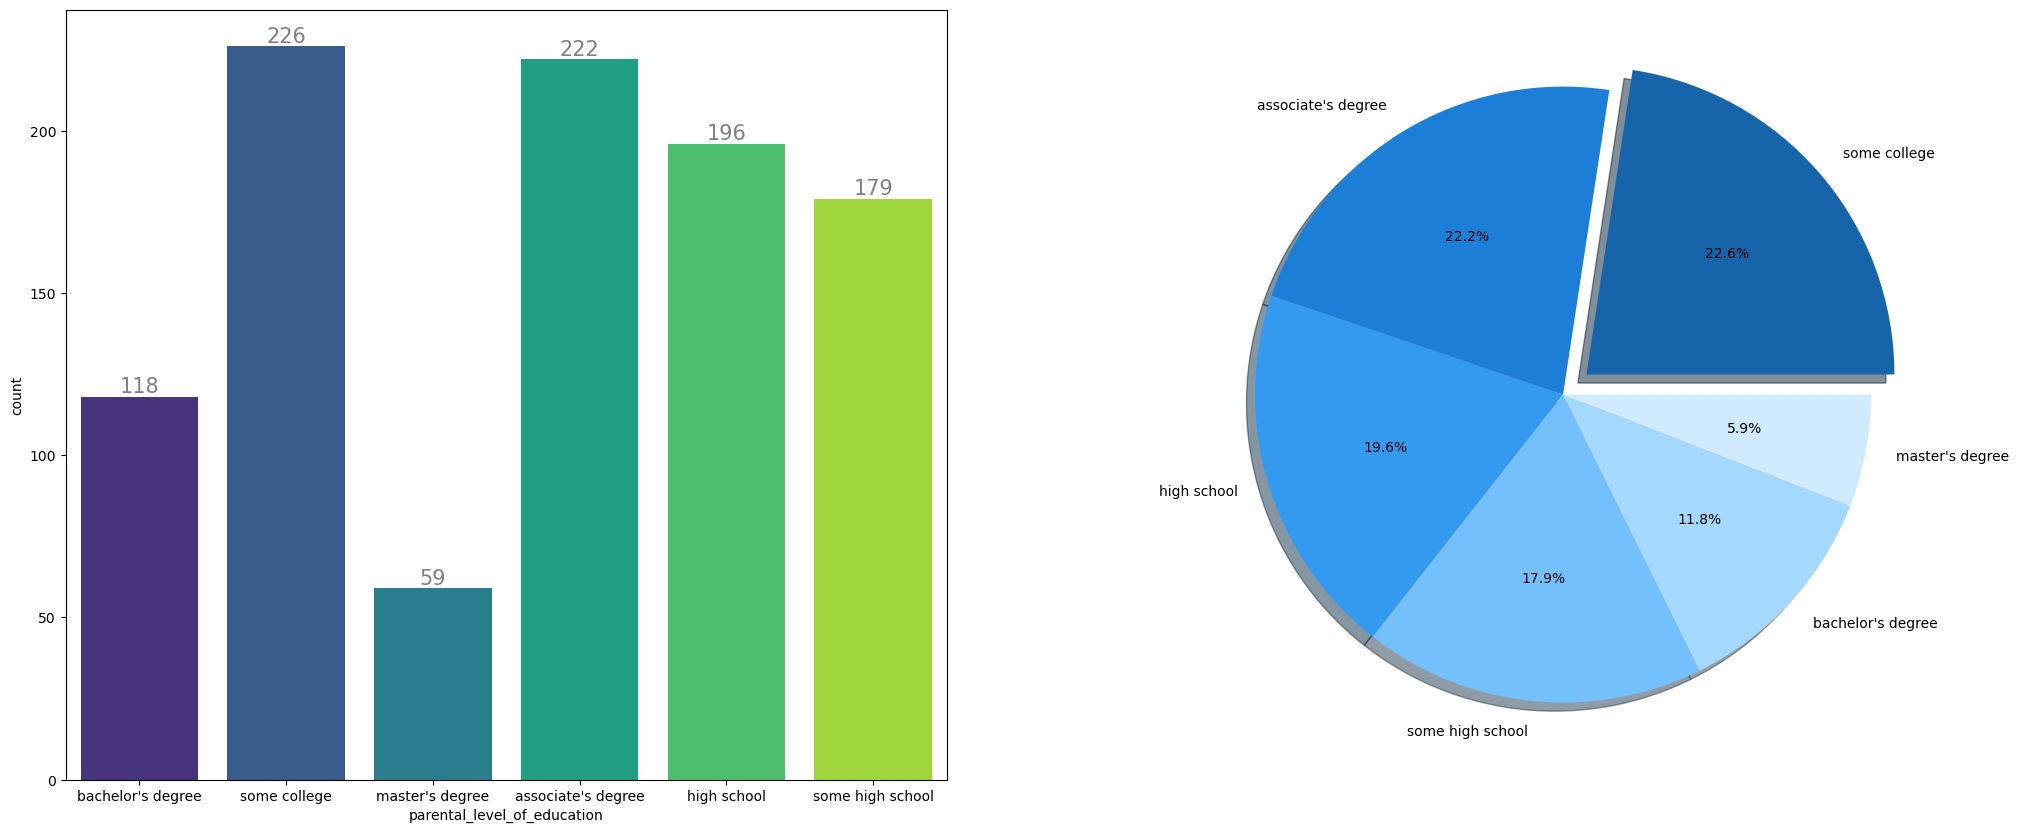

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(25, 10))

sns.countplot(
    data=df,
    x="parental_level_of_education",
    palette="viridis",
    ax=ax[0],
    saturation=0.95,
)
for container in ax[0].containers:
    ax[0].bar_label(container, color="grey", size=15)

plt.pie(
    x=df["parental_level_of_education"].value_counts(),
    labels=df["parental_level_of_education"].value_counts().index,
    autopct="%1.1f%%",
    explode=[0.1, 0, 0, 0, 0, 0],
    shadow=True,
    colors=c2,
)

plt.show()

The educational background of students parent are mostly associate's degree and some college.


**BIVARIATE ANALYSIS (Is parental education has any impact on student's performance?)**


In [32]:
parental_group = df.groupby("parental_level_of_education")[
    ["math_score", "reading_score", "writing_score", "total_score", "average"]
].mean()
parental_group

,math_score,reading_score,writing_score,total_score,average
parental_level_of_education,,,,,
associate's degree,67.882883,70.927928,69.896396,208.707207,69.569069
bachelor's degree,69.389831,73.000000,73.381356,215.771186,71.923729
high school,62.137755,64.704082,62.448980,189.290816,63.096939
master's degree,69.745763,75.372881,75.677966,220.796610,73.598870
some college,67.128319,69.460177,68.840708,205.429204,68.476401
some high school,63.497207,66.938547,64.888268,195.324022,65.108007


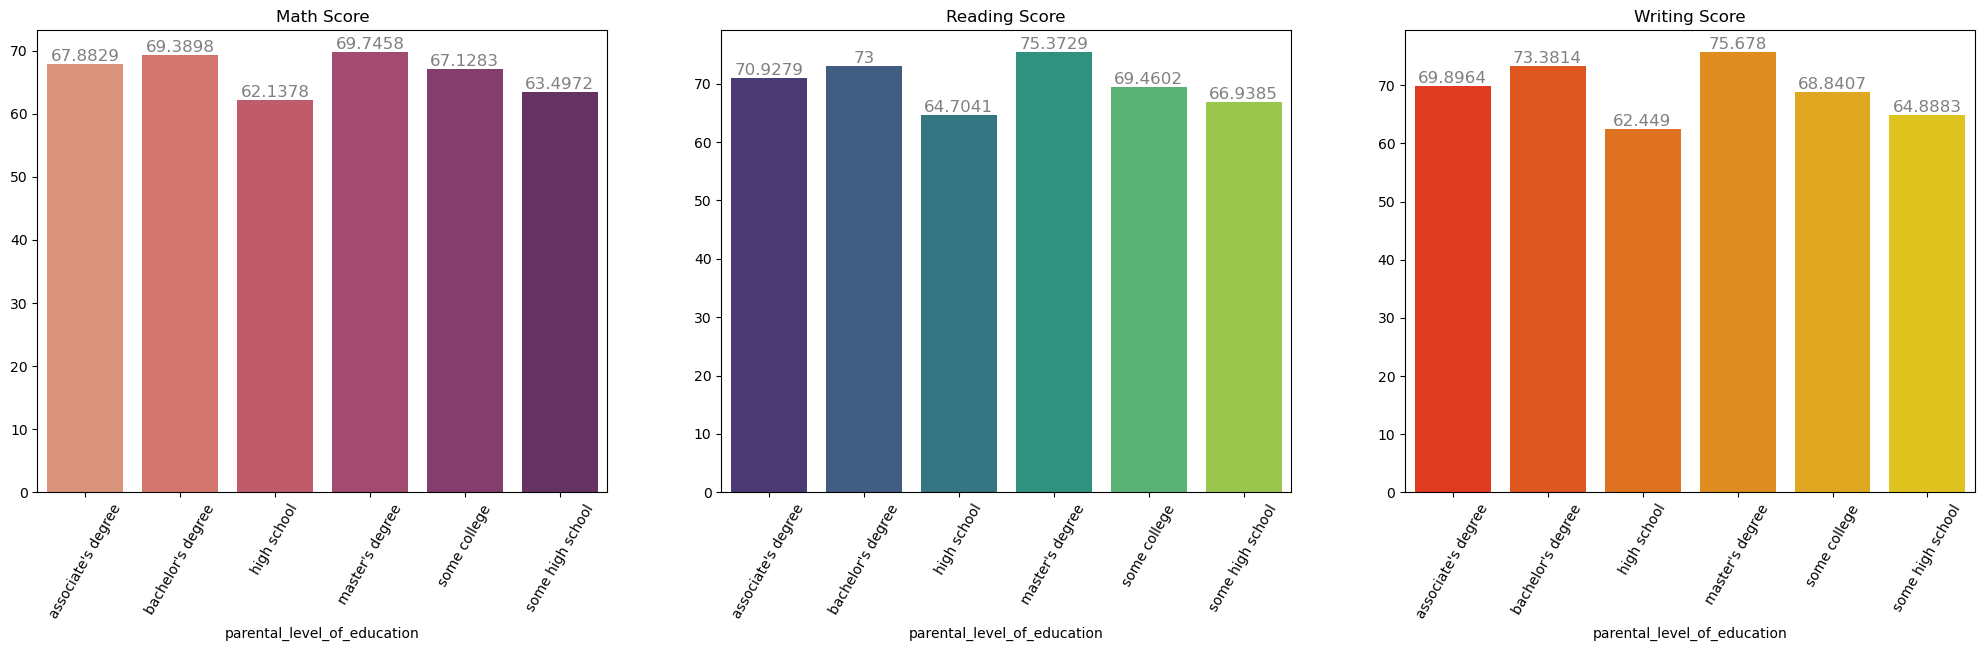

In [33]:
fig, ax = plt.subplots(1, 3, figsize=(25, 6))

sns.barplot(
    x=parental_group["math_score"].index,
    y=parental_group["math_score"].values,
    ax=ax[0],
    palette="flare",
)
ax[0].set_title("Math Score")
ax[0].set_xticks(ticks=np.arange(0, 6), rotation=60, labels=parental_group.index)
for container in ax[0].containers:
    ax[0].bar_label(container, color="grey", size=12)

sns.barplot(
    x=parental_group["reading_score"].index,
    y=parental_group["reading_score"].values,
    ax=ax[1],
    palette="viridis",
)
ax[1].set_title("Reading Score")
ax[1].set_xticks(ticks=np.arange(0, 6), rotation=60, labels=parental_group.index)
for container in ax[1].containers:
    ax[1].bar_label(container, color="grey", size=12)

sns.barplot(
    x=parental_group["writing_score"].index,
    y=parental_group["writing_score"].values,
    ax=ax[2],
    palette="autumn",
)
ax[2].set_title("Writing Score")
ax[2].set_xticks(ticks=np.arange(0, 6), rotation=60, labels=parental_group.index)
for container in ax[2].containers:
    ax[2].bar_label(container, color="grey", size=12)

plt.show()

- The highest score is held by the students whose the parents have master's degree followed by bachelor's degree.
- Based on the visualization, it is evident that parental education background has an impact on exam scores. However, it is important to note that in our case, parents with a master's or bachelor's degree represent the two smallest groups in terms of distribution.


##### 4.4.4 LUNCH COLUMN

- Which type of lunch is most common amoung students?
- What is the effect of lunch type on test results?


**UNIVARIATE ANALYSIS (Which type of lunch is most common amoung students?)**


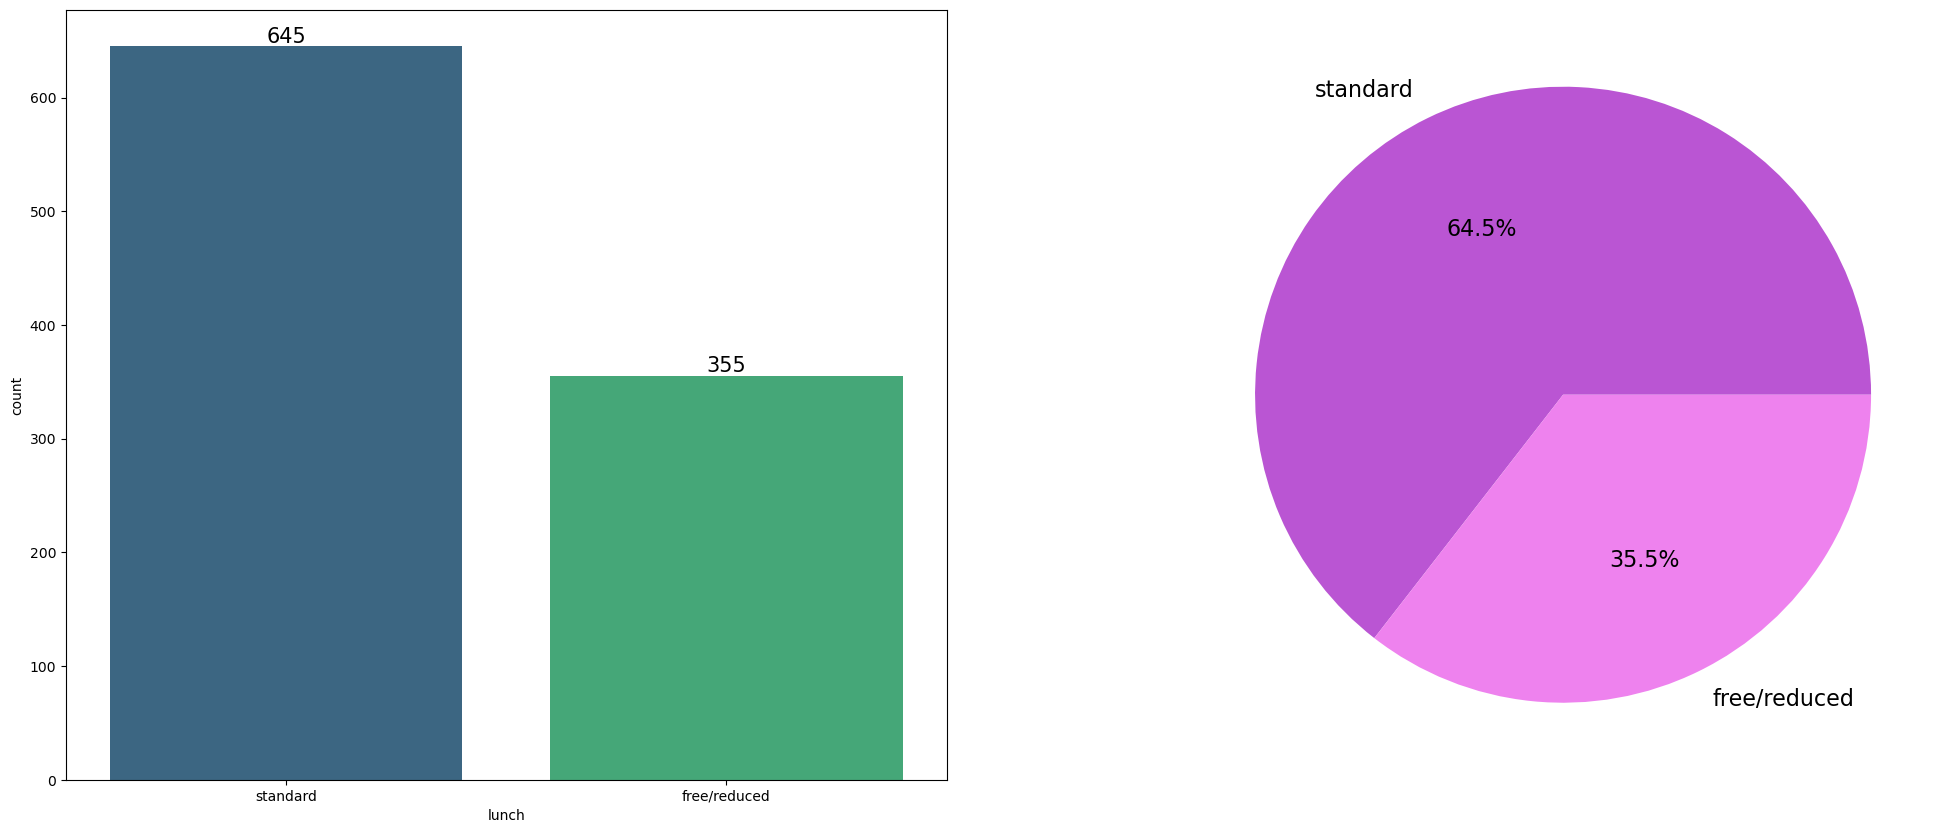

In [65]:
fig, ax = plt.subplots(1, 2, figsize=(25, 10))
sns.countplot(data=df, x="lunch", palette="viridis", ax=ax[0])
for container in ax[0].containers:
    ax[0].bar_label(container, color="black", size=15)

plt.pie(
    x=df["lunch"].value_counts(),
    labels=df["lunch"].value_counts().index,
    colors=c1,
    autopct="%1.1f%%",
    textprops={"size": 16},
)

plt.show()

Most of students commonly do standard lunch. only 35% of students who do free lunch.


**BIVARIATE ANALYSIS (What is the effect of lunch type on test results?)**


In [69]:
lunch_group = df.groupby("lunch")[
    ["math_score", "reading_score", "writing_score", "total_score", "average"]
].mean()
lunch_group

,math_score,reading_score,writing_score,total_score,average
lunch,,,,,
free/reduced,58.921127,64.653521,63.022535,186.597183,62.199061
standard,70.034109,71.654264,70.823256,212.511628,70.837209


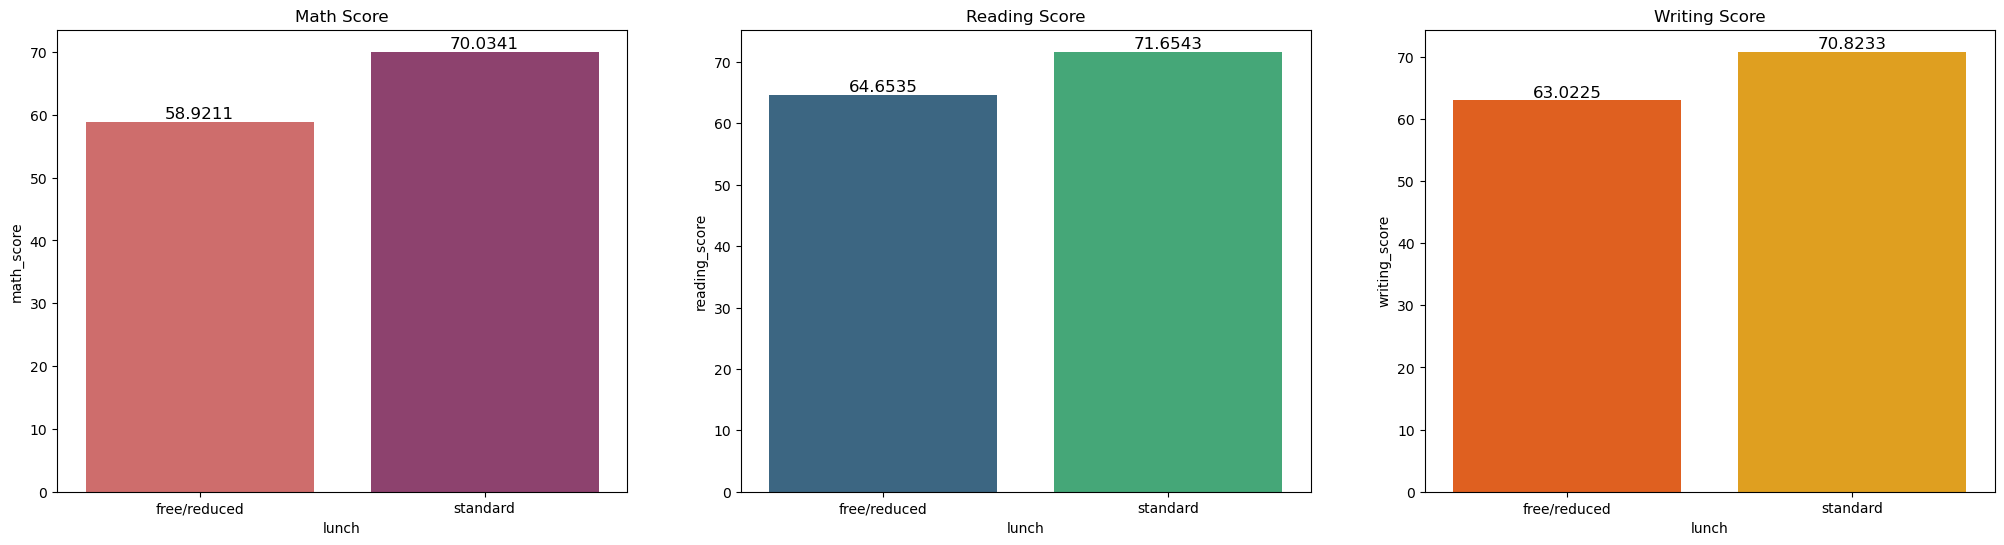

In [85]:
fig, ax = plt.subplots(1, 3, figsize=(25, 6))

sns.barplot(
    data=lunch_group, x=lunch_group.index, y="math_score", palette="flare", ax=ax[0]
)
ax[0].set_title("Math Score")
for container in ax[0].containers:
    ax[0].bar_label(container, color="black", size=12)

sns.barplot(
    data=lunch_group,
    x=lunch_group.index,
    y="reading_score",
    palette="viridis",
    ax=ax[1],
)
ax[1].set_title("Reading Score")
for container in ax[1].containers:
    ax[1].bar_label(container, color="black", size=12)

sns.barplot(
    data=lunch_group, x=lunch_group.index, y="writing_score", palette="autumn", ax=ax[2]
)
ax[2].set_title("Writing Score")
for container in ax[2].containers:
    ax[2].bar_label(container, color="black", size=12)

plt.show()

Students who had standard lunch have better performance in three subject rather than having free/reduced lunch


##### 4.4.5 TEST PREPARATION COURSE COLUMN

- Which type of lunch is most common amoung students ?
- Is Test prepration course has any impact on student's performance ?


<Axes: xlabel='lunch', ylabel='writing_score'>

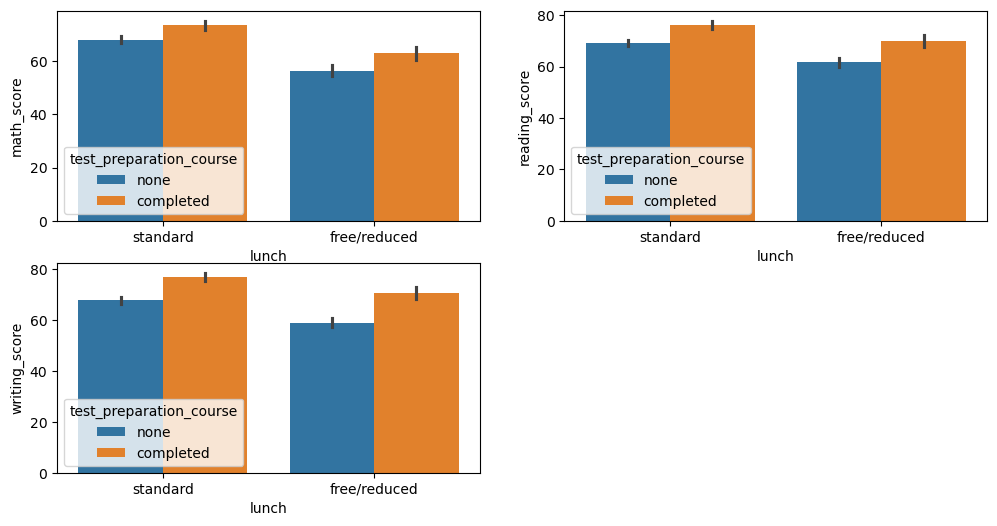

In [88]:
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
sns.barplot(x=df["lunch"], y=df["math_score"], hue=df["test_preparation_course"])
plt.subplot(2, 2, 2)
sns.barplot(x=df["lunch"], y=df["reading_score"], hue=df["test_preparation_course"])
plt.subplot(2, 2, 3)
sns.barplot(x=df["lunch"], y=df["writing_score"], hue=df["test_preparation_course"])

- There are two types of preparation course status, none and completed.
- Students who took test preparation course have better performance in all subjects


##### 4.4.6 Checking Outlier


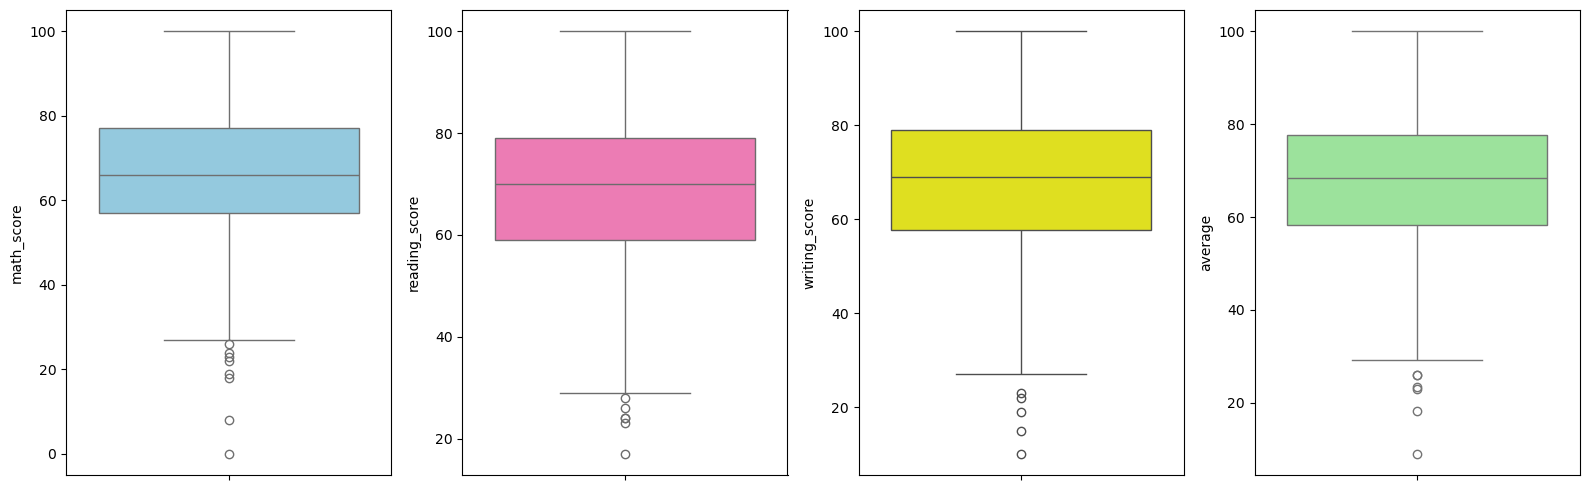

In [91]:
plt.subplots(1, 4, figsize=(16, 5))
plt.subplot(141)
sns.boxplot(df["math_score"], color="skyblue")
plt.subplot(142)
sns.boxplot(df["reading_score"], color="hotpink")
plt.subplot(143)
sns.boxplot(df["writing_score"], color="yellow")
plt.subplot(144)
sns.boxplot(df["average"], color="lightgreen")

plt.tight_layout()

plt.show()

##### 4.4.7 Multivariate Analysis with Pair Plot


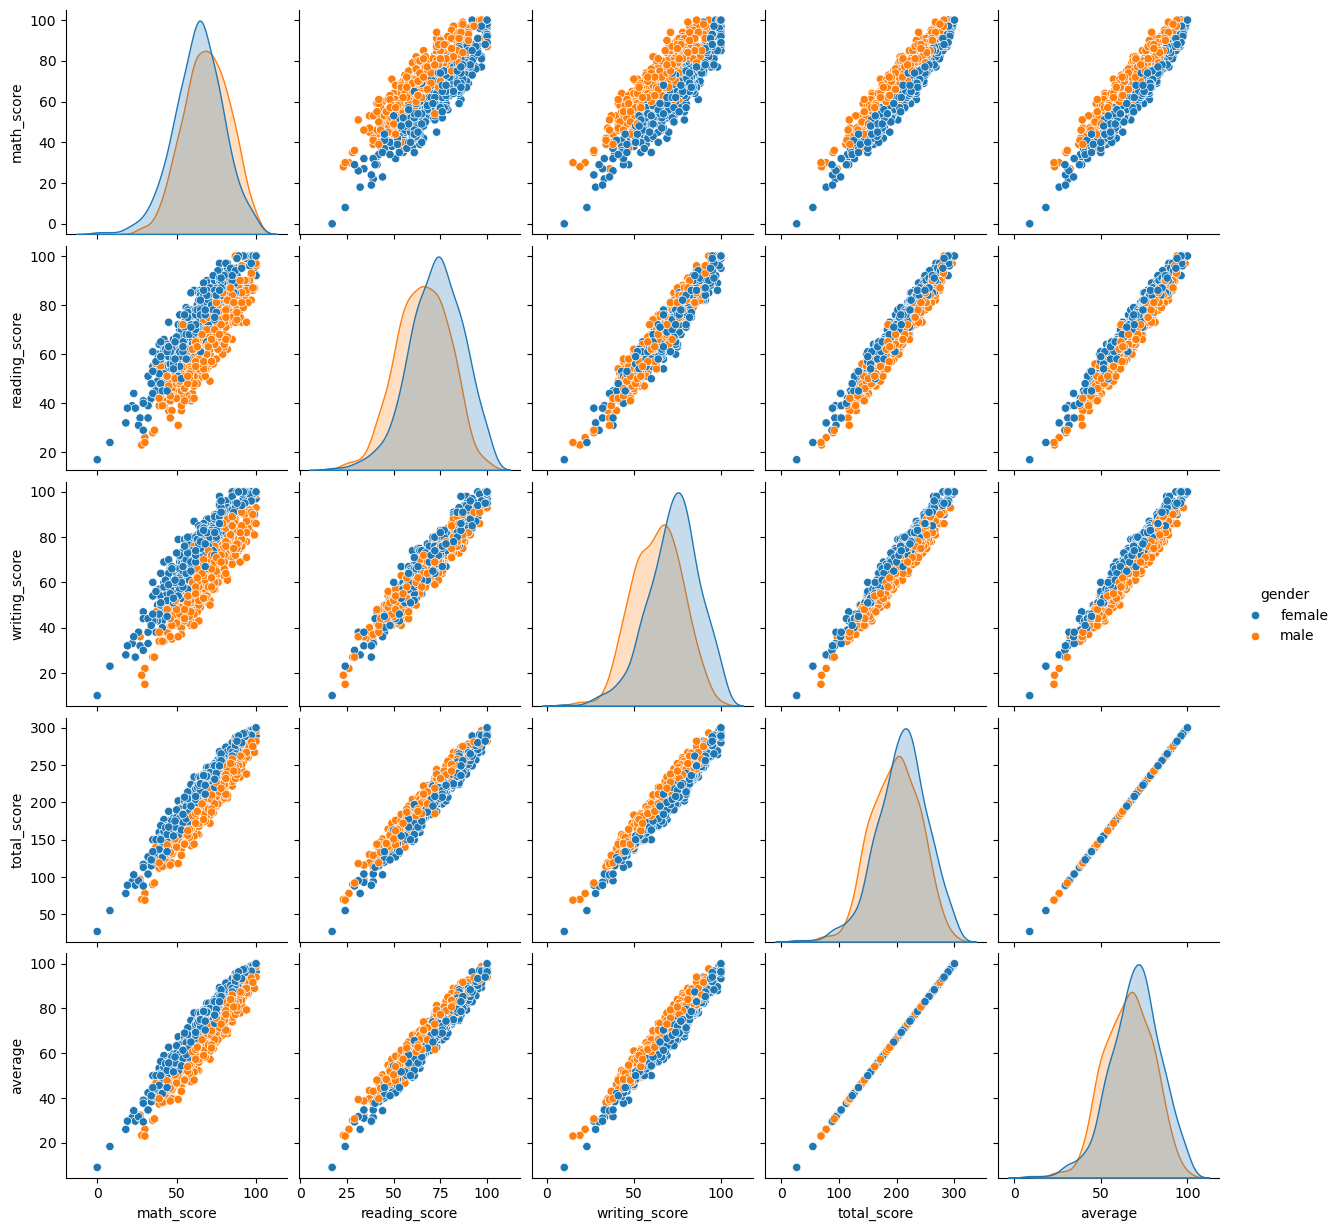

In [92]:
sns.pairplot(df, hue="gender")
plt.show()

All of the score are highly correlated each other linearly


### 5. Conclusion


- Females leads in pass percentage and also are top scorer
- Type of lunch, parental level of education, and race affect student performance
- Finishing preparation courses are benefecial to increase performance score
